This dataset represents a comprehensive record of crime incidents within the City of Los Angeles, starting from 2020 to 2025.

Objective of the Analysis:

The objective of this analysis is to perform Exploratory Data Analysis (EDA) on a dataset that records crime incidents within the City of Los Angeles from 2020 to 2025. This analysis aims to uncover key trends, patterns, and insights related to crime occurrences over time and across different locations.

Specifically, the analysis will focus on:

Understanding Crime Trends – Identifying how crime rates have changed over the years and detecting any seasonal or time-based patterns.

Crime Distribution by Location – Mapping crime hotspots and analyzing which neighborhoods experience higher crime rates.

Crime Type Analysis – Examining the frequency of different crime types and their variations over time.

Temporal Patterns – Analyzing when crimes occur most frequently (time of day, day of the week, seasonal variations).

Victim Demographics (if available) – Understanding how age, gender, and other demographic factors relate to crime incidents.

Law Enforcement Response – Evaluating police response times and arrest rates for different crime categories.

Outlier Detection & Anomalies – Detecting unusual crime spikes or anomalies in the dataset.

Final Goal
The insights gained from this EDA will help in crime prevention strategies, law enforcement resource allocation, and policymaking to improve public safety in Los Angeles. Additionally, this analysis can serve as a foundation for predictive modeling to anticipate future crime trends.

STEP 1: Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

STEP 2: Reading Dataset

In [2]:
df=pd.read_csv("D:/DataScience/Exercise/Crime_Data_from_2020_to_Present.csv")
print (df)

             DR_NO               Date Rptd                DATE OCC  TIME OCC  \
0        190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130   
1        200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800   
2        200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700   
3        200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037   
4        200412582  09/09/2020 12:00:00 AM  09/09/2020 12:00:00 AM       630   
...            ...                     ...                     ...       ...   
1004842  240710284  07/24/2024 12:00:00 AM  07/23/2024 12:00:00 AM      1400   
1004843  240104953  01/15/2024 12:00:00 AM  01/15/2024 12:00:00 AM       100   
1004844  240410786  10/14/2024 12:00:00 AM  10/11/2024 12:00:00 AM      2330   
1004845  240309674  04/24/2024 12:00:00 AM  04/24/2024 12:00:00 AM      1500   
1004846  240910892  08/13/2024 12:00:00 AM  08/12/2024 12:00:00 AM      2300   

         AREA   AREA NAME  Rpt Dist No 

STEP 3: Data Structure

In [3]:
# shape: shape will show how many features (columns) and observations (rows) there are in the dataset
df.shape

(1004847, 28)

In [ ]:
# Diaplay the first 5 rows of the dataframe
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [5]:
#A quick and informative overview of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004847 entries, 0 to 1004846
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004847 non-null  int64  
 1   Date Rptd       1004847 non-null  object 
 2   DATE OCC        1004847 non-null  object 
 3   TIME OCC        1004847 non-null  int64  
 4   AREA            1004847 non-null  int64  
 5   AREA NAME       1004847 non-null  object 
 6   Rpt Dist No     1004847 non-null  int64  
 7   Part 1-2        1004847 non-null  int64  
 8   Crm Cd          1004847 non-null  int64  
 9   Crm Cd Desc     1004847 non-null  object 
 10  Mocodes         853256 non-null   object 
 11  Vict Age        1004847 non-null  int64  
 12  Vict Sex        860243 non-null   object 
 13  Vict Descent    860231 non-null   object 
 14  Premis Cd       1004831 non-null  float64
 15  Premis Desc     1004259 non-null  object 
 16  Weapon Used Cd  327193 non-null   fl

In [6]:
# Generate descriptive statistics of DataFrame columns
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004847e+06,1.004847e+06,1.004847e+06,1.004847e+06,1.004847e+06,1.004847e+06,1.004847e+06,1.004831e+06,327193.000000,1.004836e+06,69130.000000,2315.000000,64.00000,1.004847e+06,1.004847e+06
mean,2.202171e+08,1.339911e+03,1.069147e+01,1.115607e+03,1.400307e+00,5.001353e+02,2.891905e+01,3.056073e+02,363.944543,4.998958e+02,958.115941,984.022030,991.21875,3.399820e+01,-1.180908e+02
std,1.318835e+07,6.510691e+02,6.110286e+00,6.111622e+02,4.899607e-01,2.052622e+02,2.199224e+01,2.192915e+02,123.741225,2.050627e+02,110.359911,52.340476,27.06985,1.610827e+00,5.582785e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106168e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209158e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311101e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521040e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [ ]:
#  Show the Data type of each column
df.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

Step 4: Data Cleaning and Preprocessing

In [8]:
# Missing Values in the Dataset
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151591
Vict Age                0
Vict Sex           144604
Vict Descent       144616
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677654
Weapon Desc        677654
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935717
Crm Cd 3          1002532
Crm Cd 4          1004783
LOCATION                0
Cross Street       850626
LAT                     0
LON                     0
dtype: int64

In [9]:
# Describe which rows in the DataFrame are duplicated and not
df.duplicated().sum()

0

In [10]:
#  Extract a list of dataframe column
df.columns.tolist()

['DR_NO',
 'Date Rptd',
 'DATE OCC',
 'TIME OCC',
 'AREA',
 'AREA NAME',
 'Rpt Dist No',
 'Part 1-2',
 'Crm Cd',
 'Crm Cd Desc',
 'Mocodes',
 'Vict Age',
 'Vict Sex',
 'Vict Descent',
 'Premis Cd',
 'Premis Desc',
 'Weapon Used Cd',
 'Weapon Desc',
 'Status',
 'Status Desc',
 'Crm Cd 1',
 'Crm Cd 2',
 'Crm Cd 3',
 'Crm Cd 4',
 'LOCATION',
 'Cross Street',
 'LAT',
 'LON']

In [ ]:
# Replace space with "_" and caplitalize

for i in df:
    #print(i)
    j=i.replace(' ','_')
    #print(j)
    df=df.rename(columns={i:j.capitalize()})

In [12]:
# Returns the number of unique values for each column
df.nunique()

Dr_no             1004847
Date_rptd            1840
Date_occ             1826
Time_occ             1439
Area                   21
Area_name              21
Rpt_dist_no          1210
Part_1-2                2
Crm_cd                140
Crm_cd_desc           140
Mocodes            310796
Vict_age              104
Vict_sex                5
Vict_descent           20
Premis_cd             314
Premis_desc           306
Weapon_used_cd         79
Weapon_desc            79
Status                  6
Status_desc             6
Crm_cd_1              142
Crm_cd_2              126
Crm_cd_3               38
Crm_cd_4                6
Location            66564
Cross_street        10413
Lat                  5426
Lon                  4982
dtype: int64

In [13]:
# Replace the NULL values with a specified value
df.fillna

<bound method NDFrame.fillna of              Dr_no               Date_rptd                Date_occ  Time_occ  \
0        190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130   
1        200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800   
2        200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700   
3        200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037   
4        200412582  09/09/2020 12:00:00 AM  09/09/2020 12:00:00 AM       630   
...            ...                     ...                     ...       ...   
1004842  240710284  07/24/2024 12:00:00 AM  07/23/2024 12:00:00 AM      1400   
1004843  240104953  01/15/2024 12:00:00 AM  01/15/2024 12:00:00 AM       100   
1004844  240410786  10/14/2024 12:00:00 AM  10/11/2024 12:00:00 AM      2330   
1004845  240309674  04/24/2024 12:00:00 AM  04/24/2024 12:00:00 AM      1500   
1004846  240910892  08/13/2024 12:00:00 AM  08/12/2024 12:00:00 AM      2300   

       

In [14]:
# Drop the columns needed

df = df.drop(columns=['Crm_cd_3', 'Crm_cd_4'])
print("\nDataFrame after dropping 'Crm_cd_3' and 'Crm_cd_4' columns:\n", df)



DataFrame after dropping 'Crm_cd_3' and 'Crm_cd_4' columns:
              Dr_no               Date_rptd                Date_occ  Time_occ  \
0        190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130   
1        200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800   
2        200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700   
3        200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037   
4        200412582  09/09/2020 12:00:00 AM  09/09/2020 12:00:00 AM       630   
...            ...                     ...                     ...       ...   
1004842  240710284  07/24/2024 12:00:00 AM  07/23/2024 12:00:00 AM      1400   
1004843  240104953  01/15/2024 12:00:00 AM  01/15/2024 12:00:00 AM       100   
1004844  240410786  10/14/2024 12:00:00 AM  10/11/2024 12:00:00 AM      2330   
1004845  240309674  04/24/2024 12:00:00 AM  04/24/2024 12:00:00 AM      1500   
1004846  240910892  08/13/2024 12:00:00 AM  08/12/2024 12:

Step 5:  Data Structure after data cleaning

In [15]:
# show how many features (columns) and observations (rows) there are in the dataset
df.shape

(1004847, 26)

In [16]:
#  Access to the column names of a DataFrame
df.columns

Index(['Dr_no', 'Date_rptd', 'Date_occ', 'Time_occ', 'Area', 'Area_name',
       'Rpt_dist_no', 'Part_1-2', 'Crm_cd', 'Crm_cd_desc', 'Mocodes',
       'Vict_age', 'Vict_sex', 'Vict_descent', 'Premis_cd', 'Premis_desc',
       'Weapon_used_cd', 'Weapon_desc', 'Status', 'Status_desc', 'Crm_cd_1',
       'Crm_cd_2', 'Location', 'Cross_street', 'Lat', 'Lon'],
      dtype='object')

In [17]:
# Print information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004847 entries, 0 to 1004846
Data columns (total 26 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Dr_no           1004847 non-null  int64  
 1   Date_rptd       1004847 non-null  object 
 2   Date_occ        1004847 non-null  object 
 3   Time_occ        1004847 non-null  int64  
 4   Area            1004847 non-null  int64  
 5   Area_name       1004847 non-null  object 
 6   Rpt_dist_no     1004847 non-null  int64  
 7   Part_1-2        1004847 non-null  int64  
 8   Crm_cd          1004847 non-null  int64  
 9   Crm_cd_desc     1004847 non-null  object 
 10  Mocodes         853256 non-null   object 
 11  Vict_age        1004847 non-null  int64  
 12  Vict_sex        860243 non-null   object 
 13  Vict_descent    860231 non-null   object 
 14  Premis_cd       1004831 non-null  float64
 15  Premis_desc     1004259 non-null  object 
 16  Weapon_used_cd  327193 non-null   fl

In [18]:
# Statistical Summary
df.describe(include='all')

,Dr_no,Date_rptd,Date_occ,Time_occ,Area,Area_name,Rpt_dist_no,Part_1-2,Crm_cd,Crm_cd_desc,...,Weapon_used_cd,Weapon_desc,Status,Status_desc,Crm_cd_1,Crm_cd_2,Location,Cross_street,Lat,Lon
count,1.004847e+06,1004847,1004847,1.004847e+06,1.004847e+06,1004847,1.004847e+06,1.004847e+06,1.004847e+06,1004847,...,327193.000000,327193,1004846,1004847,1.004836e+06,69130.000000,1004847,154221,1.004847e+06,1.004847e+06
unique,NaN,1840,1826,NaN,NaN,21,NaN,NaN,NaN,140,...,NaN,79,6,6,NaN,NaN,66564,10413,NaN,NaN
top,NaN,02/02/2023 12:00:00 AM,01/01/2020 12:00:00 AM,NaN,NaN,Central,NaN,NaN,NaN,VEHICLE - STOLEN,...,NaN,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,NaN,NaN,800 N ALAMEDA ST,BROADWAY,NaN,NaN
freq,NaN,929,1163,NaN,NaN,69671,NaN,NaN,NaN,115184,...,NaN,174721,804413,804413,NaN,NaN,2598,2486,NaN,NaN
mean,2.202171e+08,NaN,NaN,1.339911e+03,1.069147e+01,NaN,1.115607e+03,1.400307e+00,5.001353e+02,NaN,...,363.944543,NaN,NaN,NaN,4.998958e+02,958.115941,NaN,NaN,3.399820e+01,-1.180908e+02
std,1.318835e+07,NaN,NaN,6.510691e+02,6.110286e+00,NaN,6.111622e+02,4.899607e-01,2.052622e+02,NaN,...,123.741225,NaN,NaN,NaN,2.050627e+02,110.359911,NaN,NaN,1.610827e+00,5.582785e+00
min,8.170000e+02,NaN,NaN,1.000000e+00,1.000000e+00,NaN,1.010000e+02,1.000000e+00,1.100000e+02,NaN,...,101.000000,NaN,NaN,NaN,1.100000e+02,210.000000,NaN,NaN,0.000000e+00,-1.186676e+02
25%,2.106168e+08,NaN,NaN,9.000000e+02,5.000000e+00,NaN,5.870000e+02,1.000000e+00,3.310000e+02,NaN,...,311.000000,NaN,NaN,NaN,3.310000e+02,998.000000,NaN,NaN,3.401470e+01,-1.184305e+02
50%,2.209158e+08,NaN,NaN,1.420000e+03,1.100000e+01,NaN,1.139000e+03,1.000000e+00,4.420000e+02,NaN,...,400.000000,NaN,NaN,NaN,4.420000e+02,998.000000,NaN,NaN,3.405890e+01,-1.183225e+02
75%,2.311101e+08,NaN,NaN,1.900000e+03,1.600000e+01,NaN,1.613000e+03,2.000000e+00,6.260000e+02,NaN,...,400.000000,NaN,NaN,NaN,6.260000e+02,998.000000,NaN,NaN,3.416490e+01,-1.182739e+02


Step 6: Visualizing Distributions

Q1. What are the most common types of crimes reported?

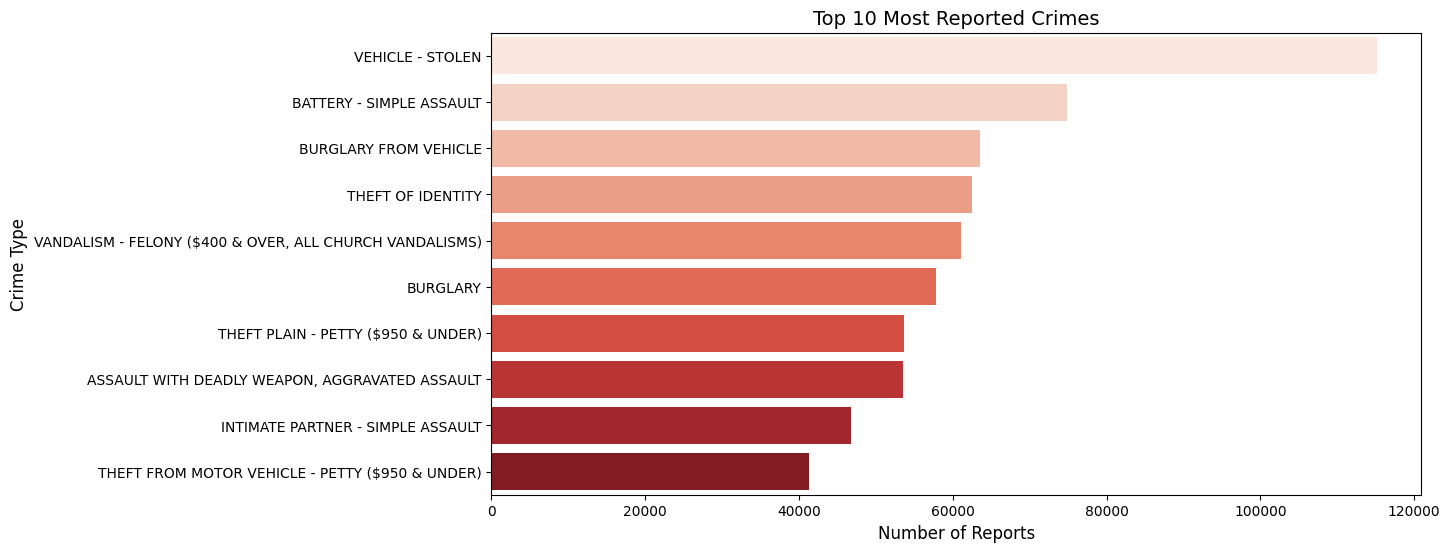

In [ ]:

top_crimes = df['Crm_cd_desc'].value_counts().nlargest(10)  

plt.figure(figsize=(12, 6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="Reds")

plt.title("Top 10 Most Reported Crimes", fontsize=14)
plt.xlabel("Number of Reports", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)
plt.show()


Vehicle theft, assault, and burglary are the most common crimes reported. 
Property-related offenses like theft and vandalism are also significant concerns

Q2. What is the distribution of crime based on each Area?

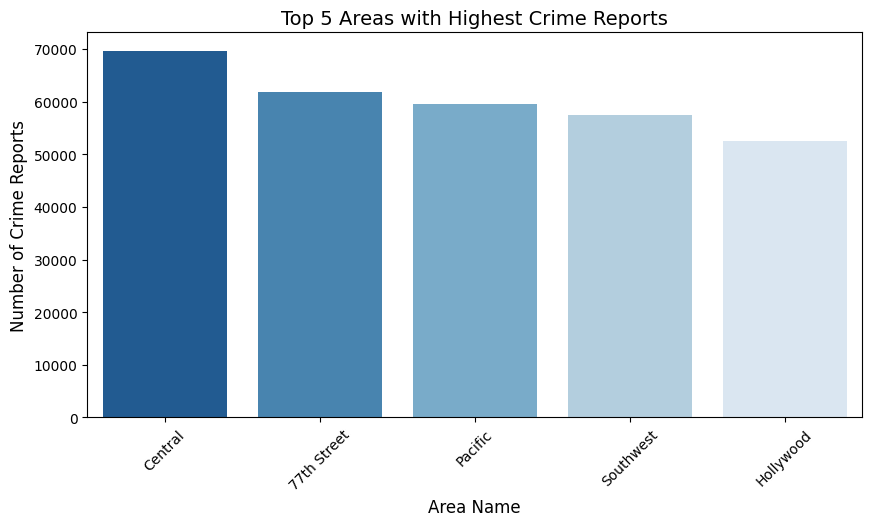

In [20]:

top_areas = df['Area_name'].value_counts().nlargest(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_areas.index, y=top_areas.values, palette="Blues_r")
plt.title("Top 5 Areas with Highest Crime Reports", fontsize=14)
plt.xlabel("Area Name", fontsize=12)
plt.ylabel("Number of Crime Reports", fontsize=12)
plt.xticks(rotation=45)
plt.show()


Crime is most common in Central, with 77th Street and Pacific also being high-crime areas. 
These places may need extra safety measures

Q3. What are the Time-Based Trends of crime each year? 

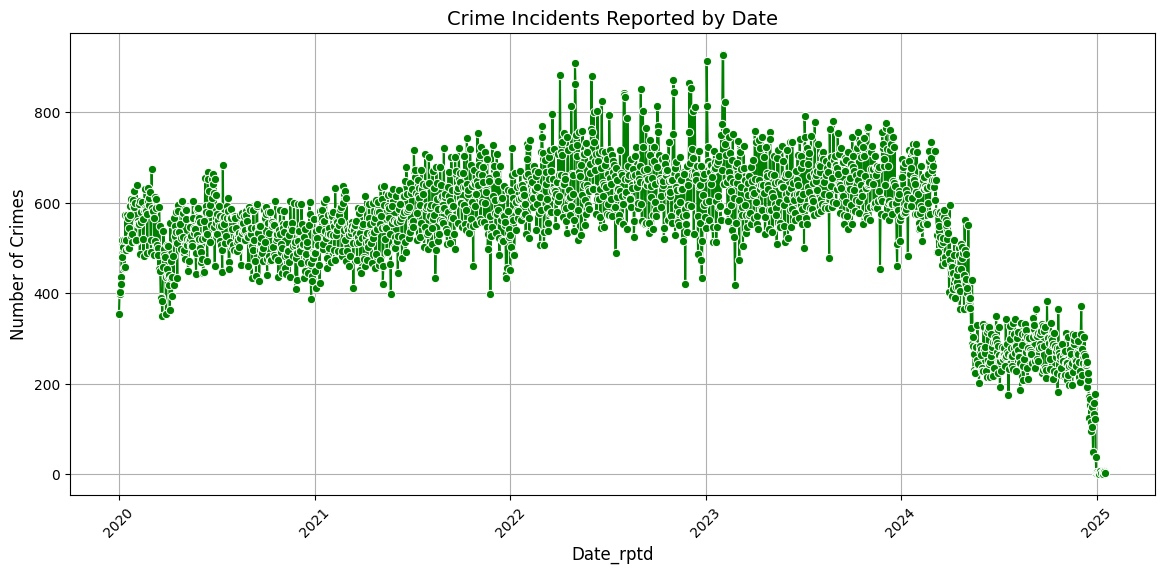

In [ ]:

df['Date_rptd'] = pd.to_datetime(df['Date_rptd'])

crime_by_date = df['Date_rptd'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x=crime_by_date.index, y=crime_by_date.values, marker='o', color='green')

plt.title("Crime Incidents Reported by Date", fontsize=14)
plt.xlabel("Date_rptd", fontsize=12)
plt.ylabel("Number of Crimes", fontsize=12)
plt.xticks(rotation=45) 
plt.grid(True)
plt.show()



Crime was rising from 2020 to 2023 but started dropping significantly in 2024. 

This could be due to better policing or changes in crime patterns.

Q4. Identify the Victim involved in most crimes based on Age and Gender

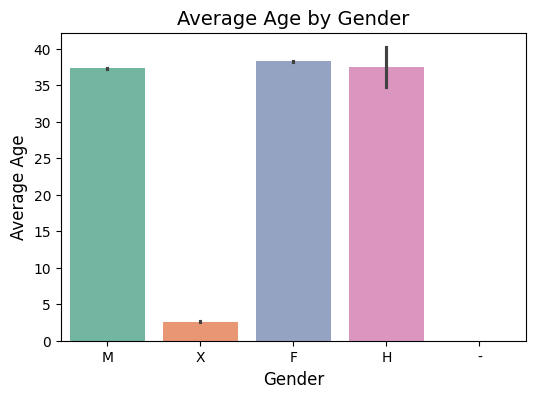

In [ ]:

plt.figure(figsize=(6, 4))
sns.barplot(x='Vict_sex', y='Vict_age', data=df, estimator=lambda x: x.mean(), palette='Set2')

plt.title("Average Age by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Age", fontsize=12)
plt.show()



The victims most involved in crimes are usually young adults and middle-aged individuals, with males often being more affected than females.

However, the trend may vary depending on the type of crime

Q5.  Which are the top  Premises where the crime is done mostly?

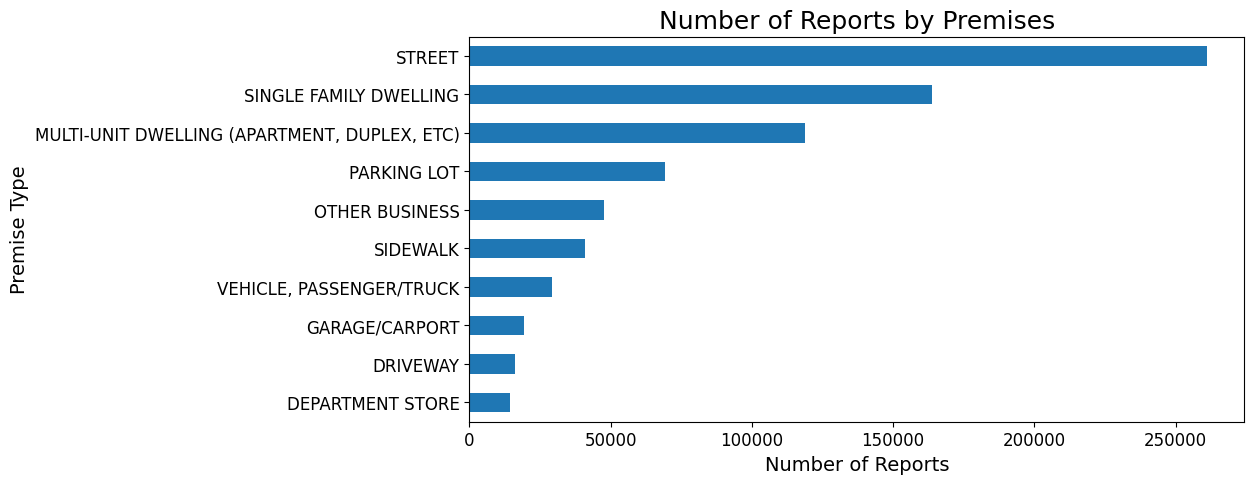

In [ ]:

df['Premis_desc'].value_counts().sort_values(ascending=True).tail(10).plot(kind='barh', figsize=(10,5))

plt.xlabel ('Number of Reports', fontsize=14)
plt.ylabel ('Premise Type', fontsize=14)
plt.xticks (fontsize=12)
plt.yticks (fontsize=12)
plt.title  ('Number of Reports by Premises', fontsize=18)
plt.show()



Crimes mostly occur on streets, parking areas, homes, and business places. 
These areas may need better security.

Q6. Identify the Total Crimes by Hours, To now the most common time where crime is done?

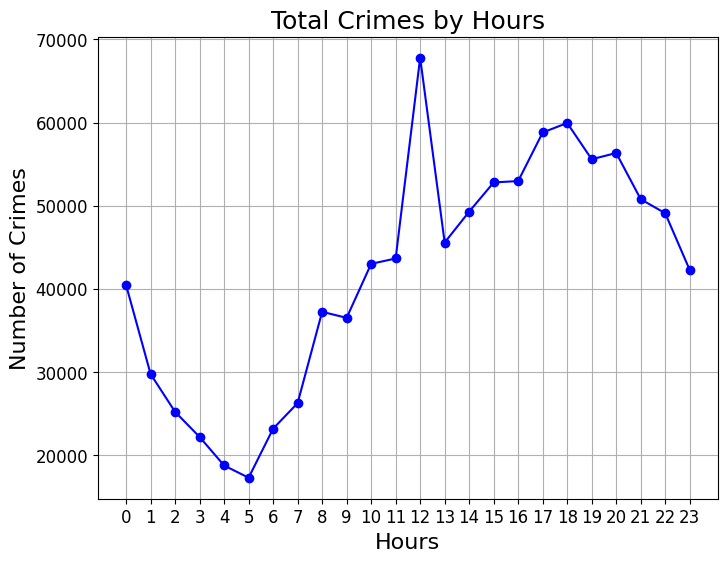

In [ ]:

columns = ['Area_name', 'Crm_cd_desc', 'Time_occ']
df = df[columns]

df['Hours'] = df['Time_occ'] // 100

hourly_crimes = df.groupby('Hours').size().reset_index(name='Total Crimes')

plt.figure(figsize=(8,6))
plt.plot(hourly_crimes['Hours'], hourly_crimes['Total Crimes'], marker='o', linestyle='-', color='b')
plt.grid(True)
plt.xlabel('Hours', fontsize=16)
plt.ylabel('Number of Crimes', fontsize=16)
plt.xticks(range(24), fontsize=12)
plt.yticks(fontsize=12)
plt.title('Total Crimes by Hours', fontsize=18)
plt.show()



Crime is most common in the afternoon  and evening , so extra safety measures may be needed during these hours.
The data indicates that crime incidents are more frequent in the afternoon and evening hours, suggesting that these periods may be higher-risk times for criminal activity. This trend could be influenced by factors such as increased foot traffic, social activities, and business operations during these hours


Q7. Find  the top 10 most used weapons during the period 2020 to 2025?

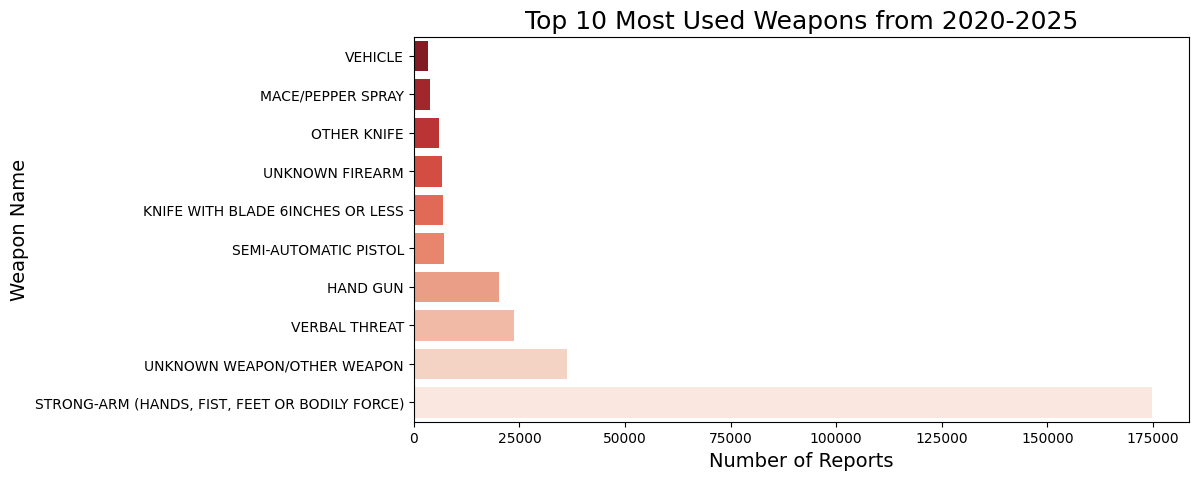

In [ ]:

top_weapons = df['Weapon_desc'].value_counts().nlargest(10).sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=top_weapons.values, y=top_weapons.index, palette="Reds_r")

plt.xlabel('Number of Reports', fontsize=14)
plt.ylabel('Weapon Name', fontsize=14)
plt.title('Top 10 Most Used Weapons from 2020-2025', fontsize=18)

plt.show()



The most commonly used weapons in crimes from 2020 to 2025 is  strong arm weapon which may refer to a Nerf Elite Strongarm blaster. 
unknown weapons  are often the most frequently used, indicating a major role in violent crimes

Q8.  Find the Status Distribution?

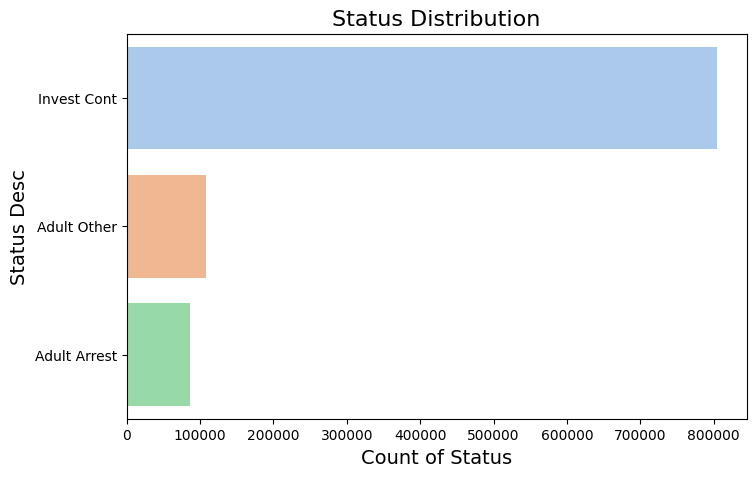

In [ ]:

status_counts = df['Status_desc'].value_counts().head(3)

colors = sns.color_palette("pastel", len(status_counts))
plt.figure(figsize=(8, 5))
sns.barplot(x=status_counts.values, y=status_counts.index, palette=colors)
plt.xlabel('Count of Status', fontsize=14)
plt.ylabel('Status Desc', fontsize=14)
plt.title('Status Distribution', fontsize=16)
plt.show()

Many cases are still under investigation, while some lead to arrests.
1.Most cases are still under investigation.
2.Some cases lead to arrests, while others remain unresolved.
3.A few cases get closed due to lack of evidence or other reasons.

Q9. What is the top crime code found in crime code 1?

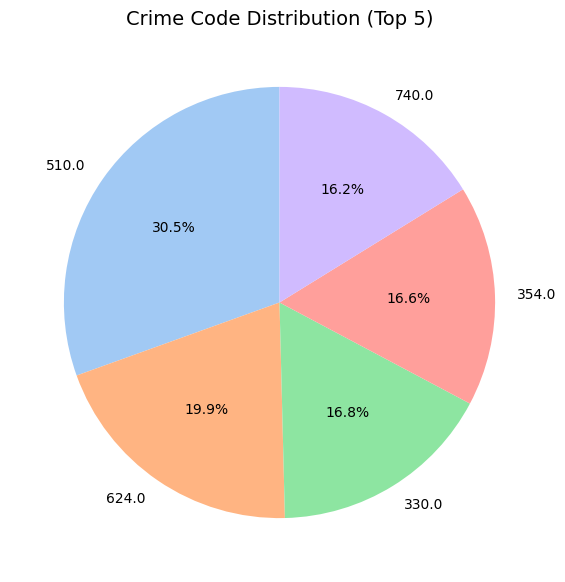

In [ ]:
top_crimes_pie = df['Crm_cd_1'].value_counts().head(5)

plt.figure(figsize=(7, 7))
plt.pie(top_crimes_pie, labels=top_crimes_pie.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=90)

plt.title("Crime Code Distribution (Top 5)", fontsize=14)

plt.show()

Helps to find the highest crime code based on which can ease the investigation.

Q10. What is the top crime code found in crime code 2?


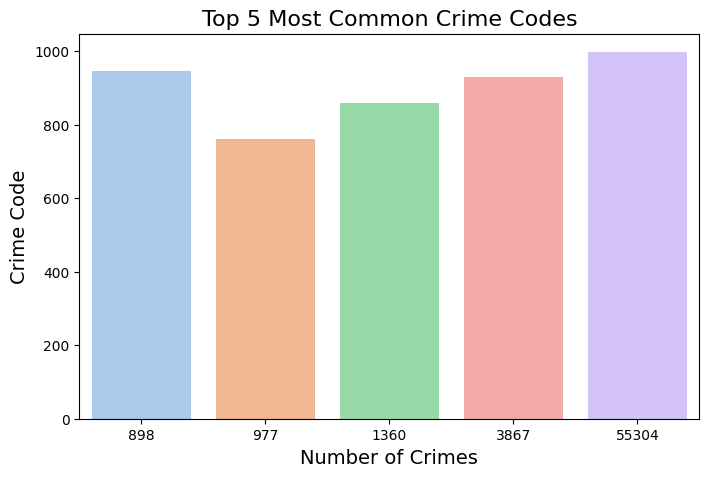

In [ ]:

top_crimes = df['Crm_cd_2'].value_counts().head(5)

# Plot bar graph
plt.figure(figsize=(8, 5))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="pastel")

# Labels and title
plt.xlabel('Number of Crimes', fontsize=14)
plt.ylabel('Crime Code', fontsize=14)
plt.title('Top 5 Most Common Crime Codes', fontsize=16)

# Show plot
plt.show()

Comparing both the the graphs we can get a hint of higest crime code happened .


Q11. What is the geographical distribution of crimes based on latitude and longitude?

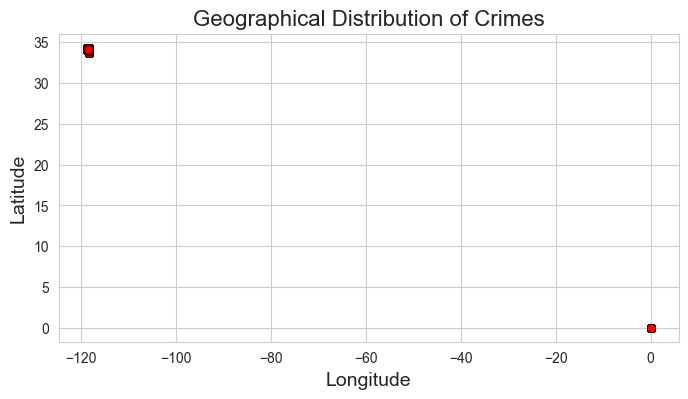

In [ ]:
plt.figure(figsize=(8, 4))  
sns.set_style("whitegrid")
sns.scatterplot(x=df['Lon'], y=df['Lat'], alpha=0.5, color='red', edgecolor='k')

# Labels and title
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)
plt.title("Geographical Distribution of Crimes", fontsize=16)

# Show plot
plt.show()

High-density clusters in specific regions suggest crime-prone areas.
Certain locations have higher crime activity, potentially requiring law enforcement focus.
This visualization can help in identifying crime hotspots for further analysis and action.

Many cases are still under investigation, while some lead to arrests, and others remain unsolved
  1.Most cases are still under investigation.
  2.Some cases lead to arrests, while others remain unresolved.
  3.A few cases get closed due to lack of evidence or other reasons.

Crime Prevention Steps Based on Findings.

After analyzing the dataset (crime_file), the following steps can be taken for crime prevention:

Increase Law Enforcement in High-Crime Areas

Identify regions with high crime rates and deploy more patrols.
Use hotspot policing to concentrate efforts where crime is most frequent.
Improve Community Safety Initiatives

Implement neighborhood watch programs.
Increase street lighting and surveillance cameras.
Strengthen community policing and encourage public reporting.
Targeted Crime Reduction Strategies

Address the most frequently used weapons in crimes by improving weapons regulations.
Implement early intervention programs for at-risk youth.
Strengthen laws against repeat offenders.
Data-Driven Policing

Use predictive analytics to allocate resources dynamically.
Monitor crime trends and adjust policies accordingly.

Conclusion & Next Steps
<!-- Findings -->

Crime is rising in certain months—more patrols needed during these periods.
High-crime areas identified—law enforcement should focus resources here.
Common crime types—awareness campaigns can target these offenses.

<!-- Next Steps -->

Use machine learning (ARIMA, Random Forest) to predict future crime.
Implement real-time dashboards for law enforcement.
Improve community engagement with safety programs.